# Random Forest 피부층 다중 예측

**입력**: 힐버트 엔벨로프 피크 특징 벡터 (29개 — 진피·근막·뼈 구간)  
**출력**:
- `dermis_mm` — 진피 깊이 (항상 예측)
- `fascia_mm` — 근막 깊이 (있을 수도 없을 수도)
- `bone_mm` — 뼈 깊이 (있을 수도 없을 수도)

**모델**: Random Forest / XGBoost — 회귀(3개) + 분류(존재 여부 2개)  
**평가**: LOO-CV (환자별 검증)

## 0. 환경 설정

In [1]:
import re, json, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.font_manager as fm

from scipy.signal import hilbert, find_peaks
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.multioutput import MultiOutputClassifier
import warnings
warnings.filterwarnings('ignore')

try:
    import xgboost as xgb
    HAS_XGB = True
    print('XGBoost 사용 가능')
except ImportError:
    HAS_XGB = False
    print('XGBoost 없음 → sklearn GradientBoosting 사용')

# 한글 폰트
_ko_candidates = [f.fname for f in fm.fontManager.ttflist if 'Noto Sans CJK' in f.name]
if _ko_candidates:
    fm.fontManager.addfont(_ko_candidates[0])
    _ko_name = fm.FontProperties(fname=_ko_candidates[0]).get_name()
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = [_ko_name, 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

ROOT       = Path('.').resolve()
USDATA     = ROOT / 'usdata' / 'data'
RESULT_DIR = ROOT / 'results'
RESULT_DIR.mkdir(exist_ok=True)

TRIM_START     = 1850
TRIM_COUNT     = 2050
DISPLAY_OFFSET = 18.50
SAMPLE_PERIOD  = 0.01   # μs/sample
SOUND_SPEED    = 1540.0

T0_THRESHOLD       = 100.0
DERMIS_EXPECTED_US = 2.33
DERMIS_STD_US      = 0.33
FASCIA_EXPECTED_US = 5.16
FASCIA_STD_US      = 0.79
BONE_MIN_US        = 6.0    # T0 기준 뼈 탐색 시작
BONE_MAX_US        = 11.5   # T0 기준 뼈 탐색 종료

FILENAME_RE = re.compile(
    r'^(?P<name>.+)_(?P<date>\d{8})_(?P<time>\d{6})_'
    r'\((?P<pos_num>\d+)\)(?P<position>.+?)_(?P<gender>[MF])\.csv$'
)

print(f'USDATA : {USDATA}')
print(f'Results: {RESULT_DIR}')

XGBoost 없음 → sklearn GradientBoosting 사용
USDATA : /home/dmjang/work/ultrasound_analysis/usdata/data
Results: /home/dmjang/work/ultrasound_analysis/results


## 1. 데이터 로드

In [2]:
def load_adc_stored(path):
    adc = []
    with open(path, encoding='utf-8', errors='replace') as fh:
        for line in fh:
            line = line.strip()
            if not line: continue
            try:
                v = int(line)
                if 0 <= v <= 255: adc.append(v)
            except ValueError: pass
    adc = np.array(adc, dtype=np.float64)
    if len(adc) >= TRIM_START + TRIM_COUNT:
        adc = adc[TRIM_START:TRIM_START + TRIM_COUNT]
    elif len(adc) > TRIM_START:
        adc = adc[TRIM_START:]
    if len(adc) < TRIM_COUNT:
        adc = np.pad(adc, (0, TRIM_COUNT - len(adc)), constant_values=128)
    return adc[:TRIM_COUNT]


def load_label(csv_path):
    """JSON에서 T0 + 진피/근막/뼈 로드.
    fascia_mm, bone_mm 는 None 허용.
    T0 또는 진피가 없으면 None 반환 (샘플 제외).
    """
    json_path = csv_path.with_name(csv_path.stem + '_positions.json')
    if not json_path.exists(): return None
    with open(json_path, encoding='utf-8') as fh:
        data = json.load(fh)

    t0_us     = data.get('start_point_us')
    dermis_mm = fascia_mm = bone_mm = None

    for pos in data.get('positions', []):
        name = pos.get('position_name', '')
        mm   = pos.get('thickness_mm')
        if name in ('피하지방시작', 'Dermis') and mm is not None:
            dermis_mm = float(mm)
        elif name == 'Fascia' and mm is not None:
            fascia_mm = float(mm)

    be = data.get('bone_echo')
    if be and be.get('depth_mm') is not None:
        bone_mm = float(be['depth_mm'])

    if t0_us is None or dermis_mm is None: return None
    return float(t0_us), dermis_mm, fascia_mm, bone_mm


def abs_to_idx(t_us, n):
    return max(0, min(n - 1, int(round((t_us - DISPLAY_OFFSET) / SAMPLE_PERIOD))))


def build_dataset():
    rows = []
    for csv_path in sorted(USDATA.rglob('*.csv')):
        if '_positions' in csv_path.name: continue
        if '펄서' in str(csv_path): continue
        m = FILENAME_RE.match(csv_path.name)
        if not m: continue
        if int(m.group('pos_num')) == 0: continue
        label = load_label(csv_path)
        if label is None: continue
        t0_us, dermis_mm, fascia_mm, bone_mm = label
        try:
            adc = load_adc_stored(csv_path)
        except Exception:
            continue
        rows.append({
            'patient':  m.group('name'),
            'position': m.group('position'),
            'pos_num':  int(m.group('pos_num')),
            'adc':      adc,
            't0_us':    t0_us,
            'dermis':   dermis_mm,
            'fascia':   fascia_mm,   # None 허용
            'bone':     bone_mm,     # None 허용
        })
    return rows


ALL_ROWS = build_dataset()
patients = sorted({r['patient'] for r in ALL_ROWS})

n_fascia = sum(1 for r in ALL_ROWS if r['fascia'] is not None)
n_bone   = sum(1 for r in ALL_ROWS if r['bone']   is not None)
print(f'총 샘플  : {len(ALL_ROWS)}개  /  환자: {len(patients)}명')
print(f'근막 있음: {n_fascia}개 ({100*n_fascia/len(ALL_ROWS):.1f}%)')
print(f'뼈   있음: {n_bone}개 ({100*n_bone/len(ALL_ROWS):.1f}%)')
print(f'환자 목록: {patients}')

d_vals = [r['dermis'] for r in ALL_ROWS]
f_vals = [r['fascia'] for r in ALL_ROWS if r['fascia'] is not None]
b_vals = [r['bone']   for r in ALL_ROWS if r['bone']   is not None]
print(f'\n진피 평균: {np.mean(d_vals):.3f} ± {np.std(d_vals):.3f} mm  [{np.min(d_vals):.2f}~{np.max(d_vals):.2f}]')
print(f'근막 평균: {np.mean(f_vals):.3f} ± {np.std(f_vals):.3f} mm  [{np.min(f_vals):.2f}~{np.max(f_vals):.2f}]')
print(f'뼈   평균: {np.mean(b_vals):.3f} ± {np.std(b_vals):.3f} mm  [{np.min(b_vals):.2f}~{np.max(b_vals):.2f}]')

총 샘플  : 1200개  /  환자: 20명
근막 있음: 806개 (67.2%)
뼈   있음: 1082개 (90.2%)
환자 목록: ['권영남', '김선일', '김수현', '김희락', '박성수', '박인석', '박인식', '서영수', '송용범', '송인광', '양창식', '오광', '윤아영', '장동만', '정병훈', '조세일', '조현수', '한승현', '홍충만', '황인홍']

진피 평균: 1.781 ± 0.117 mm  [1.54~2.05]
근막 평균: 3.969 ± 0.064 mm  [3.76~4.13]
뼈   평균: 5.524 ± 1.120 mm  [3.08~8.59]


## 2. 피크 특징 추출

In [3]:
def window_features(env, i0, i1, expected_rel_us):
    """env[i0:i1] 구간에서 9개 특징 추출.
    expected_rel_us: 구간 시작(i0) 기준 예상 피크 μs.
    """
    seg = env[i0:i1]
    if len(seg) < 3:
        return [0.0] * 9
    rel_us  = np.arange(len(seg)) * SAMPLE_PERIOD
    mean_v  = float(np.mean(seg))
    std_v   = float(np.std(seg))
    max_v   = float(np.max(seg))
    max_i   = int(np.argmax(seg))
    max_pos = float(rel_us[max_i])

    peaks, props = find_peaks(seg, prominence=max(max_v * 0.1, 1.0), distance=3)
    if len(peaks) > 0:
        best    = int(np.argmin(np.abs(rel_us[peaks] - expected_rel_us)))
        pk_pos  = float(rel_us[peaks[best]])
        pk_amp  = float(seg[peaks[best]])
        pk_prom = float(props['prominences'][best])
    else:
        pk_pos, pk_amp, pk_prom = max_pos, max_v, 0.0

    energy = float(np.sum(seg ** 2) / max(len(seg), 1))
    return [mean_v, std_v, max_v, max_pos, pk_pos, pk_amp, pk_prom, energy, float(len(peaks))]


# 특징 이름 (29개)
FEATURE_NAMES = (
    ['t0_us', 't0_amp'] +
    [f'd_{n}' for n in ['mean','std','max','maxpos','pkpos','pkamp','pkprom','energy','npeaks']] +
    [f'f_{n}' for n in ['mean','std','max','maxpos','pkpos','pkamp','pkprom','energy','npeaks']] +
    [f'b_{n}' for n in ['mean','std','max','maxpos','pkpos','pkamp','pkprom','energy','npeaks']]
)
N_FEATURES = len(FEATURE_NAMES)  # 2 + 9*3 = 29


def extract_features(adc_stored, t0_us):
    """힐버트 엔벨로프 기반 진피·근막·뼈 구간 특징 벡터 (29차원)"""
    n   = len(adc_stored)
    env = np.abs(hilbert(adc_stored - 128.0))

    t0_idx = abs_to_idx(t0_us, n)
    t0_amp = float(env[t0_idx])

    # 진피 창 (T0 + 2.0~2.66μs)
    di0 = abs_to_idx(t0_us + DERMIS_EXPECTED_US - DERMIS_STD_US, n)
    di1 = abs_to_idx(t0_us + DERMIS_EXPECTED_US + DERMIS_STD_US, n)
    d_feats = window_features(env, di0, di1, DERMIS_STD_US)

    # 근막 창 (T0 + 4.37~5.95μs)
    fi0 = abs_to_idx(t0_us + FASCIA_EXPECTED_US - FASCIA_STD_US, n)
    fi1 = abs_to_idx(t0_us + FASCIA_EXPECTED_US + FASCIA_STD_US, n)
    f_feats = window_features(env, fi0, fi1, FASCIA_STD_US)

    # 뼈 탐색 창 (T0 + 6.0~11.5μs)
    bi0 = abs_to_idx(t0_us + BONE_MIN_US, n)
    bi1 = abs_to_idx(t0_us + BONE_MAX_US, n)
    bone_zone_center = (BONE_MAX_US - BONE_MIN_US) / 2.0   # 2.75μs (구간 중앙)
    b_feats = window_features(env, bi0, bi1, bone_zone_center)

    return np.array([t0_us, t0_amp] + d_feats + f_feats + b_feats, dtype=np.float32)


# 전체 특징 행렬 구축
X_ALL   = np.stack([extract_features(r['adc'], r['t0_us']) for r in ALL_ROWS])

# 회귀 목표 (없으면 0)
Y_REG   = np.array([
    [r['dermis'],
     r['fascia'] if r['fascia'] is not None else 0.0,
     r['bone']   if r['bone']   is not None else 0.0]
    for r in ALL_ROWS
], dtype=np.float32)

# 분류 목표 [has_fascia, has_bone]
Y_CLS   = np.array([
    [1 if r['fascia'] is not None else 0,
     1 if r['bone']   is not None else 0]
    for r in ALL_ROWS
], dtype=np.int32)

print(f'특징 행렬: {X_ALL.shape}  (샘플 × 특징)')
print(f'특징명  : {FEATURE_NAMES}')

특징 행렬: (1200, 29)  (샘플 × 특징)
특징명  : ['t0_us', 't0_amp', 'd_mean', 'd_std', 'd_max', 'd_maxpos', 'd_pkpos', 'd_pkamp', 'd_pkprom', 'd_energy', 'd_npeaks', 'f_mean', 'f_std', 'f_max', 'f_maxpos', 'f_pkpos', 'f_pkamp', 'f_pkprom', 'f_energy', 'f_npeaks', 'b_mean', 'b_std', 'b_max', 'b_maxpos', 'b_pkpos', 'b_pkamp', 'b_pkprom', 'b_energy', 'b_npeaks']


## 3. 모델 정의

In [4]:
def make_reg_rf(n_estimators=200, max_depth=None, min_samples_leaf=3):
    return RandomForestRegressor(
        n_estimators=n_estimators, max_depth=max_depth,
        min_samples_leaf=min_samples_leaf, n_jobs=-1, random_state=42)

def make_cls_rf(n_estimators=200, max_depth=None, min_samples_leaf=3):
    return MultiOutputClassifier(
        RandomForestClassifier(
            n_estimators=n_estimators, max_depth=max_depth,
            min_samples_leaf=min_samples_leaf, n_jobs=-1, random_state=42),
        n_jobs=-1)

def make_reg_xgb(n_estimators=300, max_depth=4, learning_rate=0.05,
                 subsample=0.8, colsample_bytree=0.8):
    if HAS_XGB:
        return xgb.XGBRegressor(
            n_estimators=n_estimators, max_depth=max_depth,
            learning_rate=learning_rate, subsample=subsample,
            colsample_bytree=colsample_bytree, tree_method='hist',
            random_state=42, verbosity=0)
    return GradientBoostingRegressor(
        n_estimators=n_estimators, max_depth=max_depth,
        learning_rate=learning_rate, subsample=subsample, random_state=42)

def make_cls_xgb(n_estimators=300, max_depth=4, learning_rate=0.05,
                 subsample=0.8, colsample_bytree=0.8):
    if HAS_XGB:
        base = xgb.XGBClassifier(
            n_estimators=n_estimators, max_depth=max_depth,
            learning_rate=learning_rate, subsample=subsample,
            colsample_bytree=colsample_bytree, tree_method='hist',
            use_label_encoder=False, eval_metric='logloss',
            random_state=42, verbosity=0)
    else:
        base = GradientBoostingClassifier(
            n_estimators=n_estimators, max_depth=max_depth,
            learning_rate=learning_rate, subsample=subsample, random_state=42)
    return MultiOutputClassifier(base, n_jobs=-1)


print('모델 정의 완료')

모델 정의 완료


## 4. [설정] 하이퍼파라미터

In [5]:
HP_RF = dict(
    n_estimators     = 200,
    max_depth        = None,
    min_samples_leaf = 3,
)

HP_XGB = dict(
    n_estimators     = 300,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
)

CV_MODELS = {
    'RF':  {'reg': lambda: make_reg_rf(**HP_RF),  'cls': lambda: make_cls_rf(**HP_RF)},
    'XGB': {'reg': lambda: make_reg_xgb(**HP_XGB), 'cls': lambda: make_cls_xgb(**HP_XGB)},
}

print('RF  하이퍼파라미터:', HP_RF)
print('XGB 하이퍼파라미터:', HP_XGB)
print(f'LOO-CV 대상 모델: {list(CV_MODELS.keys())}')

RF  하이퍼파라미터: {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 3}
XGB 하이퍼파라미터: {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}
LOO-CV 대상 모델: ['RF', 'XGB']


## 5. 학습 / 평가 함수

In [6]:
def train_and_eval(reg_fn, cls_fn,
                   X_tr, y_reg_tr, y_cls_tr,
                   X_val, y_reg_val, y_cls_val,
                   cls_threshold=0.5):
    """
    회귀: 진피(전체), 근막(근막 존재 샘플), 뼈(뼈 존재 샘플) 별도 학습
    분류: [has_fascia, has_bone] 공동 학습
    """
    fascia_mask_tr = y_cls_tr[:, 0] > 0
    bone_mask_tr   = y_cls_tr[:, 1] > 0

    # 회귀 모델 3개 (진피·근막·뼈)
    dermis_reg = reg_fn()
    fascia_reg = reg_fn()
    bone_reg   = reg_fn()

    dermis_reg.fit(X_tr, y_reg_tr[:, 0])
    if fascia_mask_tr.sum() >= 5:
        fascia_reg.fit(X_tr[fascia_mask_tr], y_reg_tr[fascia_mask_tr, 1])
    if bone_mask_tr.sum() >= 5:
        bone_reg.fit(X_tr[bone_mask_tr], y_reg_tr[bone_mask_tr, 2])

    # 분류 모델
    cls_model = cls_fn()
    cls_model.fit(X_tr, y_cls_tr)

    # 예측
    dermis_pred = dermis_reg.predict(X_val)
    fascia_pred = fascia_reg.predict(X_val)
    bone_pred   = bone_reg.predict(X_val)
    cls_pred    = cls_model.predict(X_val)          # (N, 2) int

    # MAE (실제 존재 샘플에서만)
    true_has_f = y_cls_val[:, 0] > 0
    true_has_b = y_cls_val[:, 1] > 0

    mae_d = float(np.mean(np.abs(dermis_pred - y_reg_val[:, 0])))
    mae_f = float(np.mean(np.abs(fascia_pred[true_has_f] - y_reg_val[true_has_f, 1]))) \
            if true_has_f.any() else float('nan')
    mae_b = float(np.mean(np.abs(bone_pred[true_has_b] - y_reg_val[true_has_b, 2]))) \
            if true_has_b.any() else float('nan')

    # 분류 정확도
    acc_f = float(np.mean(cls_pred[:, 0] == y_cls_val[:, 0]))
    acc_b = float(np.mean(cls_pred[:, 1] == y_cls_val[:, 1]))

    preds = np.stack([dermis_pred, fascia_pred, bone_pred], axis=1)  # (N, 3)
    return preds, cls_pred, mae_d, mae_f, mae_b, acc_f, acc_b


print('학습/평가 함수 정의 완료')

학습/평가 함수 정의 완료


## 6. 단일 학습 (마지막 환자 검증)

In [7]:
val_pat  = patients[-1]
pat_ids  = np.array([r['patient'] for r in ALL_ROWS])
mask_tr  = pat_ids != val_pat
mask_val = ~mask_tr

X_tr,     X_val     = X_ALL[mask_tr],   X_ALL[mask_val]
y_reg_tr, y_reg_val = Y_REG[mask_tr],   Y_REG[mask_val]
y_cls_tr, y_cls_val = Y_CLS[mask_tr],   Y_CLS[mask_val]

n_f_val = y_cls_val[:, 0].sum()
n_b_val = y_cls_val[:, 1].sum()
print(f'Train: {mask_tr.sum()}개  /  Val: {mask_val.sum()}개 (환자: {val_pat})')
print(f'Val  — 근막 있음: {n_f_val}개  뼈 있음: {n_b_val}개\n')

for name, fns in CV_MODELS.items():
    _, cls_p, mae_d, mae_f, mae_b, acc_f, acc_b = train_and_eval(
        fns['reg'], fns['cls'],
        X_tr, y_reg_tr, y_cls_tr,
        X_val, y_reg_val, y_cls_val
    )
    f_str = f'{mae_f:.4f}mm' if not np.isnan(mae_f) else 'N/A'
    b_str = f'{mae_b:.4f}mm' if not np.isnan(mae_b) else 'N/A'
    print(f'[{name}]')
    print(f'  진피  MAE : {mae_d:.4f}mm  {"✓" if mae_d < 0.3 else "✗"}')
    print(f'  근막  MAE : {f_str}  {"✓" if not np.isnan(mae_f) and mae_f < 0.3 else ""}')
    print(f'  뼈    MAE : {b_str}')
    print(f'  근막 분류 정확도: {acc_f*100:.1f}%')
    print(f'  뼈   분류 정확도: {acc_b*100:.1f}%')

Train: 1140개  /  Val: 60개 (환자: 황인홍)
Val  — 근막 있음: 43개  뼈 있음: 56개

[RF]
  진피  MAE : 0.0811mm  ✓
  근막  MAE : 0.0493mm  ✓
  뼈    MAE : 0.4362mm
  근막 분류 정확도: 90.0%
  뼈   분류 정확도: 93.3%
[XGB]
  진피  MAE : 0.0875mm  ✓
  근막  MAE : 0.0523mm  ✓
  뼈    MAE : 0.4651mm
  근막 분류 정확도: 90.0%
  뼈   분류 정확도: 91.7%


## 7. LOO-CV

In [8]:
def run_loo_cv(all_rows, X, y_reg, y_cls, model_defs):
    patients = sorted({r['patient'] for r in all_rows})
    pat_ids  = np.array([r['patient'] for r in all_rows])
    results  = {name: [] for name in model_defs}

    print(f'LOO-CV 시작: {len(patients)}명  /  모델: {list(model_defs.keys())}')
    print('-' * 84)

    for i, pat in enumerate(patients):
        m_tr  = pat_ids != pat
        m_val = ~m_tr
        Xtr, Xval         = X[m_tr],     X[m_val]
        yrt, yrv          = y_reg[m_tr], y_reg[m_val]
        yct, ycv          = y_cls[m_tr], y_cls[m_val]

        row_str = f'  [{i+1:2d}/{len(patients)}] {pat:<10s}'
        for name, fns in model_defs.items():
            preds, cls_p, mae_d, mae_f, mae_b, acc_f, acc_b = train_and_eval(
                fns['reg'], fns['cls'], Xtr, yrt, yct, Xval, yrv, ycv)
            f_str = f'{mae_f:.3f}' if not np.isnan(mae_f) else '  N/A'
            b_str = f'{mae_b:.3f}' if not np.isnan(mae_b) else '  N/A'
            row_str += (f'  [{name}] D={mae_d:.3f} F={f_str} B={b_str}'
                        f' afF={acc_f*100:.0f}% afB={acc_b*100:.0f}%')
            results[name].append({
                'patient':    pat,
                'n':          int(m_val.sum()),
                'mae_dermis': mae_d,
                'mae_fascia': mae_f,
                'mae_bone':   mae_b,
                'acc_fascia': acc_f,
                'acc_bone':   acc_b,
                'preds':      preds,
                'cls_preds':  cls_p,
                'y_reg':      yrv,
                'y_cls':      ycv,
            })
        print(row_str + f'  (n={m_val.sum()})')

    print('-' * 84)
    dfs = {}
    for name, recs in results.items():
        df = pd.DataFrame(recs)
        dfs[name] = df
        d  = df['mae_dermis'].mean()
        fv = df['mae_fascia'].dropna()
        bv = df['mae_bone'].dropna()
        print(f'  [{name}]  진피 {d:.3f}±{df["mae_dermis"].std():.3f}mm'
              f'  근막 {fv.mean():.3f}±{fv.std():.3f}mm'
              f'  뼈 {bv.mean():.3f}±{bv.std():.3f}mm'
              f'  accF={df["acc_fascia"].mean()*100:.1f}%'
              f'  accB={df["acc_bone"].mean()*100:.1f}%')
    return dfs


CV_DFS = run_loo_cv(ALL_ROWS, X_ALL, Y_REG, Y_CLS, CV_MODELS)

LOO-CV 시작: 20명  /  모델: ['RF', 'XGB']
------------------------------------------------------------------------------------
  [ 1/20] 권영남         [RF] D=0.090 F=0.051 B=0.453 afF=90% afB=92%  [XGB] D=0.087 F=0.055 B=0.477 afF=90% afB=95%  (n=60)
  [ 2/20] 김선일         [RF] D=0.085 F=0.045 B=0.423 afF=87% afB=92%  [XGB] D=0.089 F=0.042 B=0.449 afF=82% afB=95%  (n=60)
  [ 3/20] 김수현         [RF] D=0.096 F=0.048 B=0.447 afF=82% afB=95%  [XGB] D=0.104 F=0.053 B=0.491 afF=83% afB=93%  (n=60)
  [ 4/20] 김희락         [RF] D=0.096 F=0.054 B=0.534 afF=87% afB=90%  [XGB] D=0.105 F=0.056 B=0.503 afF=83% afB=88%  (n=60)
  [ 5/20] 박성수         [RF] D=0.101 F=0.064 B=0.345 afF=93% afB=93%  [XGB] D=0.104 F=0.064 B=0.329 afF=93% afB=93%  (n=60)
  [ 6/20] 박인석         [RF] D=0.094 F=0.067 B=0.350 afF=83% afB=92%  [XGB] D=0.100 F=0.072 B=0.345 afF=73% afB=95%  (n=60)
  [ 7/20] 박인식         [RF] D=0.086 F=0.048 B=0.513 afF=78% afB=85%  [XGB] D=0.084 F=0.047 B=0.484 afF=83% afB=92%  (n=60)
  [ 8/20] 서영수         [R

## 8. 결과 시각화

저장: /home/dmjang/work/ultrasound_analysis/results/randomforest_cv.png


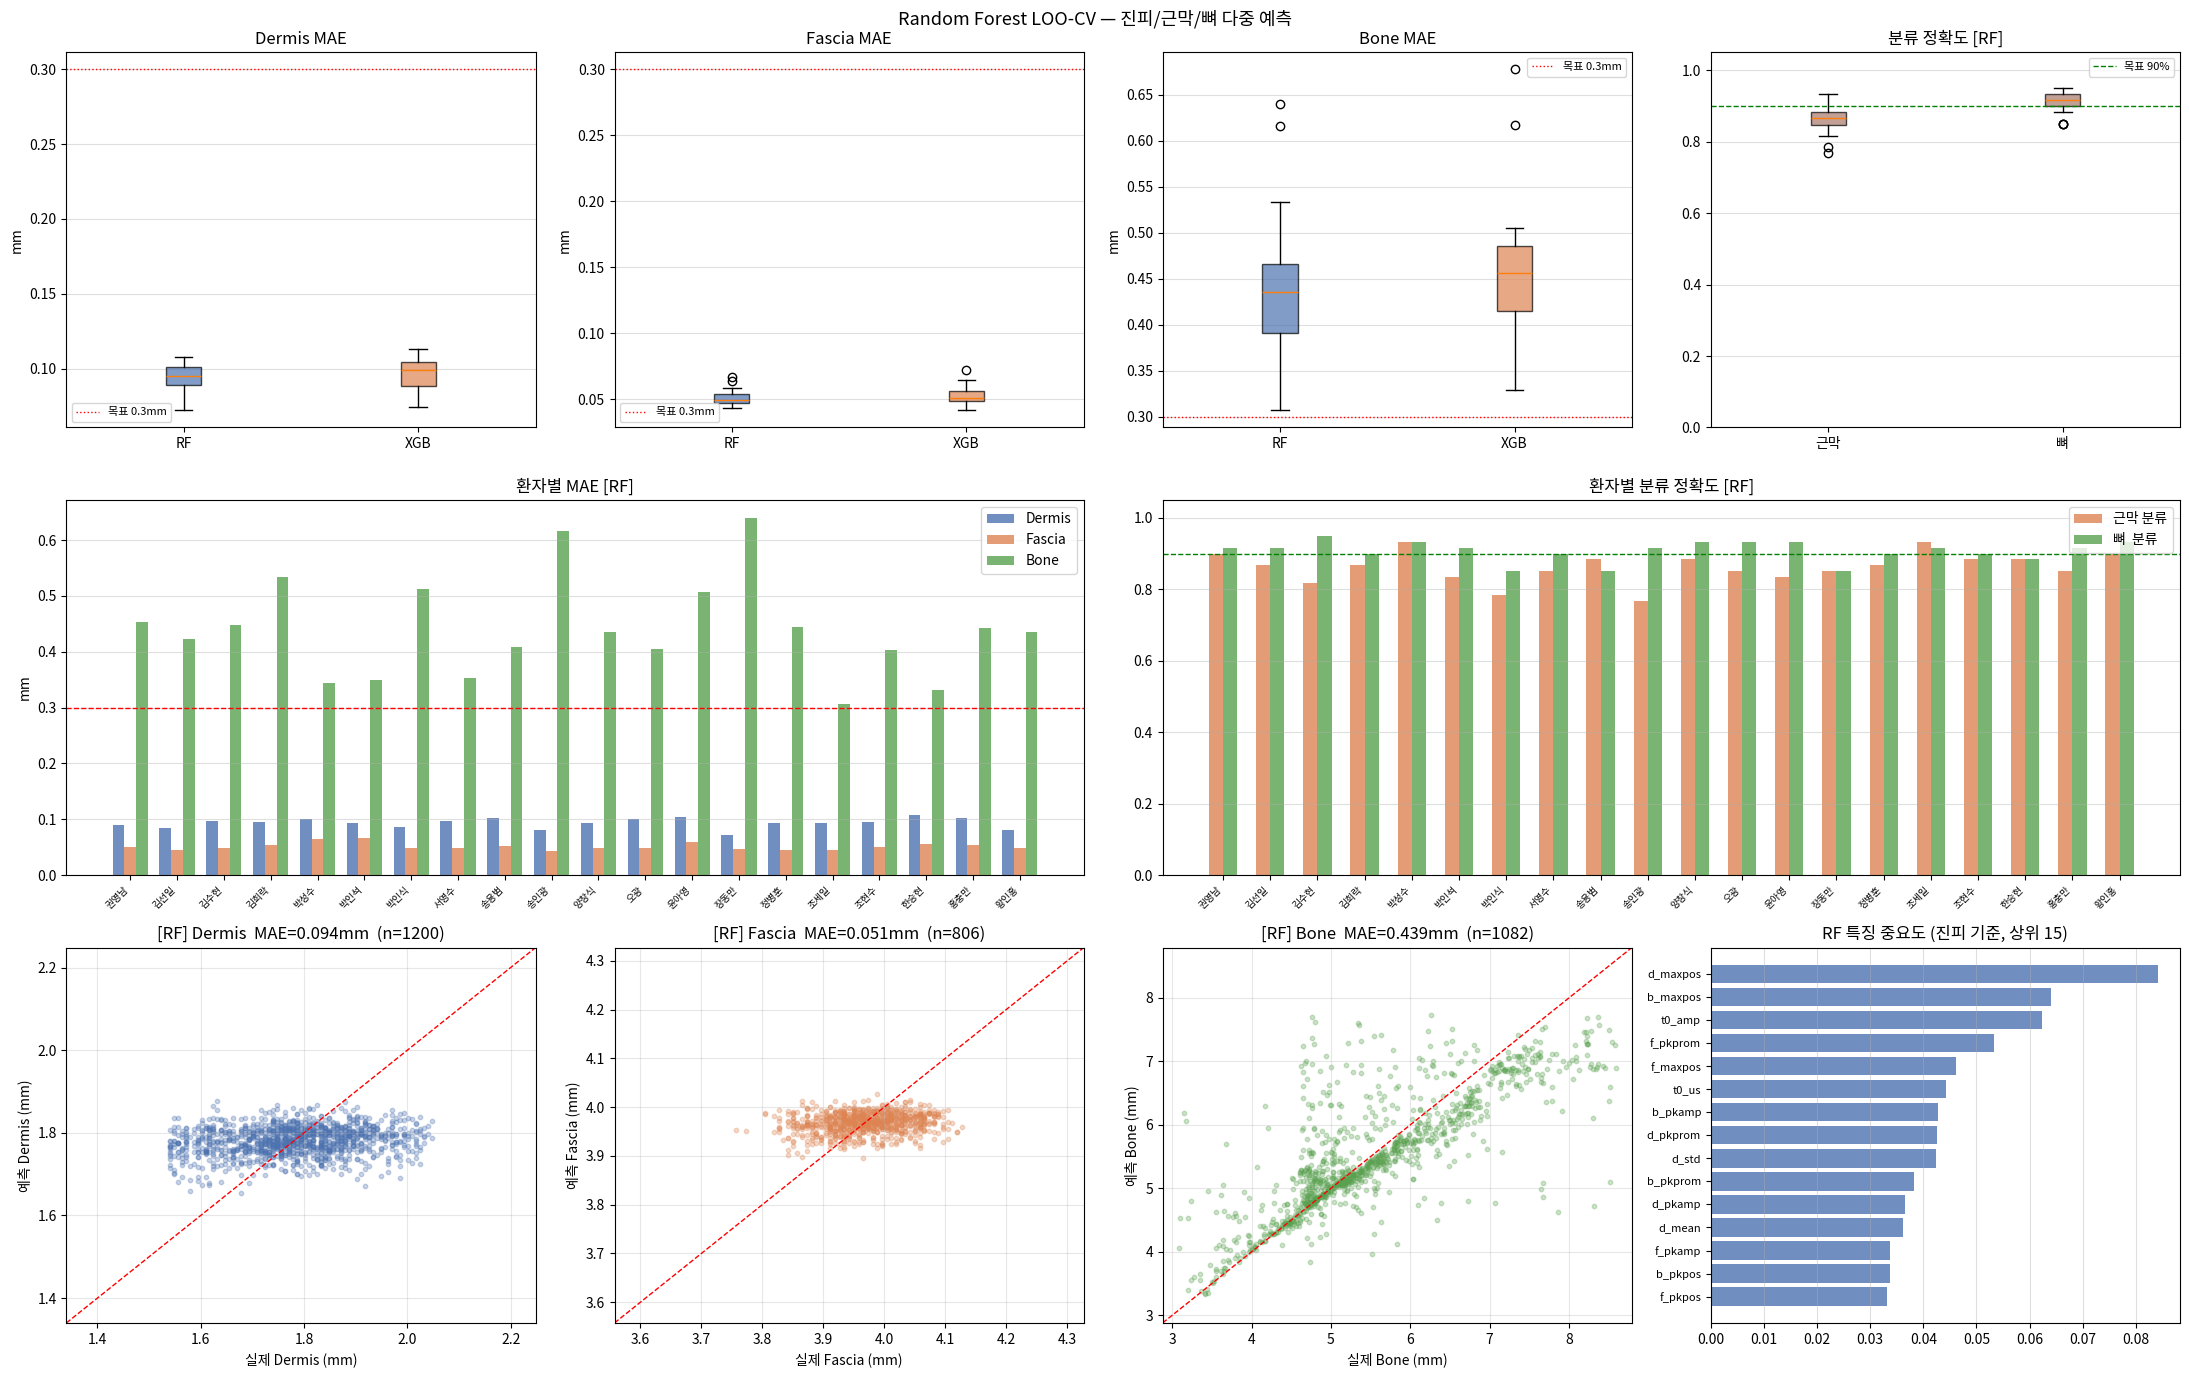

In [9]:
model_names = list(CV_DFS.keys())
best_name   = min(model_names,
    key=lambda n: CV_DFS[n]['mae_dermis'].mean() + CV_DFS[n]['mae_fascia'].dropna().mean())
colors = {'RF': '#4c72b0', 'XGB': '#dd8452'}

fig = plt.figure(figsize=(22, 14))
fig.suptitle('Random Forest LOO-CV — 진피/근막/뼈 다중 예측', fontsize=13)
gs  = gridspec.GridSpec(3, 4, figure=fig)

# ① MAE 박스플롯 3개
for ci, (key, label, col) in enumerate([
    ('mae_dermis', 'Dermis', '#4c72b0'),
    ('mae_fascia', 'Fascia', '#dd8452'),
    ('mae_bone',   'Bone',   '#59a14f'),
]):
    ax = fig.add_subplot(gs[0, ci])
    data = [CV_DFS[n][key].dropna().values for n in model_names]
    bp = ax.boxplot(data, tick_labels=model_names, patch_artist=True)
    for patch, n in zip(bp['boxes'], model_names):
        patch.set_facecolor(colors.get(n, col)); patch.set_alpha(0.7)
    ax.axhline(0.3, color='red', linestyle=':', linewidth=1, label='목표 0.3mm')
    ax.set_title(f'{label} MAE'); ax.set_ylabel('mm')
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.4)

# ② 분류 정확도 박스플롯
ax = fig.add_subplot(gs[0, 3])
bp = ax.boxplot(
    [CV_DFS[best_name]['acc_fascia'].values,
     CV_DFS[best_name]['acc_bone'].values],
    tick_labels=['근막', '뼈'], patch_artist=True,
    boxprops=dict(facecolor='#a8786a', alpha=0.7))
ax.axhline(0.9, color='green', linestyle='--', linewidth=1, label='목표 90%')
ax.set_title(f'분류 정확도 [{best_name}]'); ax.set_ylim(0, 1.05)
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.4)

# ③ 환자별 MAE 막대 (최선 모델)
ax = fig.add_subplot(gs[1, :2])
df = CV_DFS[best_name]
xx = np.arange(len(df))
ax.bar(xx - 0.25, df['mae_dermis'], 0.25, label='Dermis', color='#4c72b0', alpha=0.8)
ax.bar(xx,        df['mae_fascia'], 0.25, label='Fascia', color='#dd8452', alpha=0.8)
ax.bar(xx + 0.25, df['mae_bone'],   0.25, label='Bone',   color='#59a14f', alpha=0.8)
ax.axhline(0.3, color='red', linestyle='--', linewidth=1)
ax.set_xticks(xx)
ax.set_xticklabels(df['patient'], rotation=45, ha='right', fontsize=7)
ax.set_title(f'환자별 MAE [{best_name}]'); ax.set_ylabel('mm')
ax.legend(); ax.grid(axis='y', alpha=0.4)

# ④ 환자별 분류 정확도
ax = fig.add_subplot(gs[1, 2:])
ax.bar(xx - 0.15, df['acc_fascia'], 0.3, label='근막 분류', color='#dd8452', alpha=0.8)
ax.bar(xx + 0.15, df['acc_bone'],   0.3, label='뼈  분류',  color='#59a14f', alpha=0.8)
ax.axhline(0.9, color='green', linestyle='--', linewidth=1)
ax.set_xticks(xx)
ax.set_xticklabels(df['patient'], rotation=45, ha='right', fontsize=7)
ax.set_title(f'환자별 분류 정확도 [{best_name}]'); ax.set_ylim(0, 1.05)
ax.legend(); ax.grid(axis='y', alpha=0.4)

# ⑤⑥⑦ 예측 vs 실제 산점도
all_preds = np.concatenate([r['preds']  for r in CV_DFS[best_name].to_dict('records')])
all_y_reg = np.concatenate([r['y_reg']  for r in CV_DFS[best_name].to_dict('records')])
all_y_cls = np.concatenate([r['y_cls']  for r in CV_DFS[best_name].to_dict('records')])

for ci, (idx, label, col, mask_col) in enumerate([
    (0, 'Dermis', '#4c72b0', None),
    (1, 'Fascia', '#dd8452', 0),
    (2, 'Bone',   '#59a14f', 1),
]):
    ax = fig.add_subplot(gs[2, ci])
    if mask_col is not None:
        mask = all_y_cls[:, mask_col] > 0
        pred = all_preds[mask, idx]
        true = all_y_reg[mask, idx]
    else:
        pred = all_preds[:, idx]
        true = all_y_reg[:, idx]
    if len(pred) == 0:
        ax.text(0.5, 0.5, '데이터 없음', ha='center', transform=ax.transAxes)
        continue
    ax.scatter(true, pred, alpha=0.3, s=10, color=col)
    lim = [min(true.min(), pred.min()) - 0.2, max(true.max(), pred.max()) + 0.2]
    ax.plot(lim, lim, 'r--', linewidth=1)
    mae = float(np.mean(np.abs(pred - true)))
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f'실제 {label} (mm)'); ax.set_ylabel(f'예측 {label} (mm)')
    ax.set_title(f'[{best_name}] {label}  MAE={mae:.3f}mm  (n={len(pred)})')
    ax.grid(alpha=0.3)

# ⑧ 특징 중요도 (RF 전체 학습)
ax = fig.add_subplot(gs[2, 3])
rf_tmp = make_reg_rf(**HP_RF)
rf_tmp.fit(X_ALL, Y_REG[:, 0])   # dermis 기준으로 중요도 표시
imps = rf_tmp.feature_importances_
idx_sorted = np.argsort(imps)[::-1][:15]  # 상위 15개
ax.barh(range(15), imps[idx_sorted][::-1], color='#4c72b0', alpha=0.8)
ax.set_yticks(range(15))
ax.set_yticklabels([FEATURE_NAMES[i] for i in idx_sorted[::-1]], fontsize=8)
ax.set_title('RF 특징 중요도 (진피 기준, 상위 15)')
ax.grid(axis='x', alpha=0.4)

fig.tight_layout()
out = RESULT_DIR / 'randomforest_cv.png'
fig.savefig(out, dpi=150)
print(f'저장: {out}')
plt.show()

## 9. 최종 모델 저장

In [10]:
best_name = min(CV_MODELS.keys(),
    key=lambda n: CV_DFS[n]['mae_dermis'].mean() + CV_DFS[n]['mae_fascia'].dropna().mean())

print(f'최종 모델 학습 중 (전체 데이터, 모델={best_name})...')
fns = CV_MODELS[best_name]

fascia_mask = Y_CLS[:, 0] > 0
bone_mask   = Y_CLS[:, 1] > 0

final_dermis_reg = fns['reg']()
final_fascia_reg = fns['reg']()
final_bone_reg   = fns['reg']()
final_cls        = fns['cls']()

final_dermis_reg.fit(X_ALL, Y_REG[:, 0])
final_fascia_reg.fit(X_ALL[fascia_mask], Y_REG[fascia_mask, 1])
final_bone_reg.fit(X_ALL[bone_mask], Y_REG[bone_mask, 2])
final_cls.fit(X_ALL, Y_CLS)
print('학습 완료')

save_path = RESULT_DIR / 'best_randomforest.pkl'
with open(save_path, 'wb') as fh:
    pickle.dump({
        'model_name':       best_name,
        'dermis_reg':       final_dermis_reg,
        'fascia_reg':       final_fascia_reg,
        'bone_reg':         final_bone_reg,
        'cls_model':        final_cls,
        'feature_names':    FEATURE_NAMES,
        'n_features':       N_FEATURES,
        'display_offset_us': DISPLAY_OFFSET,
        'sample_period_us':  SAMPLE_PERIOD,
        'dermis_expected_us': DERMIS_EXPECTED_US,
        'dermis_std_us':     DERMIS_STD_US,
        'fascia_expected_us': FASCIA_EXPECTED_US,
        'fascia_std_us':     FASCIA_STD_US,
        'bone_min_us':       BONE_MIN_US,
        'bone_max_us':       BONE_MAX_US,
        'cv_mae_dermis':     {n: float(CV_DFS[n]['mae_dermis'].mean()) for n in CV_MODELS},
        'cv_mae_fascia':     {n: float(CV_DFS[n]['mae_fascia'].dropna().mean()) for n in CV_MODELS},
        'cv_mae_bone':       {n: float(CV_DFS[n]['mae_bone'].dropna().mean()) for n in CV_MODELS},
        'cv_acc_fascia':     {n: float(CV_DFS[n]['acc_fascia'].mean()) for n in CV_MODELS},
        'cv_acc_bone':       {n: float(CV_DFS[n]['acc_bone'].mean()) for n in CV_MODELS},
    }, fh)
print(f'모델 저장: {save_path}')

print(f'\n=== LOO-CV 최종 결과 ===')
for n in model_names:
    d  = CV_DFS[n]['mae_dermis'].mean()
    fv = CV_DFS[n]['mae_fascia'].dropna().mean()
    bv = CV_DFS[n]['mae_bone'].dropna().mean()
    af = CV_DFS[n]['acc_fascia'].mean()
    ab = CV_DFS[n]['acc_bone'].mean()
    mark = ' ← 최선' if n == best_name else ''
    print(f'  [{n}]  D={d:.3f}mm  F={fv:.3f}mm  B={bv:.3f}mm'
          f'  accF={af*100:.1f}%  accB={ab*100:.1f}%{mark}')

최종 모델 학습 중 (전체 데이터, 모델=RF)...
학습 완료
모델 저장: /home/dmjang/work/ultrasound_analysis/results/best_randomforest.pkl

=== LOO-CV 최종 결과 ===
  [RF]  D=0.094mm  F=0.051mm  B=0.440mm  accF=86.2%  accB=90.8% ← 최선
  [XGB]  D=0.098mm  F=0.053mm  B=0.456mm  accF=86.5%  accB=92.7%


## 10. 추론 예시

In [11]:
sample = ALL_ROWS[0]
x_feat = extract_features(sample['adc'], sample['t0_us']).reshape(1, -1)

d_pred  = final_dermis_reg.predict(x_feat)[0]
f_pred  = final_fascia_reg.predict(x_feat)[0]
b_pred  = final_bone_reg.predict(x_feat)[0]
cls_p   = final_cls.predict(x_feat)[0]   # [has_fascia, has_bone]

print(f"파일   : {sample['patient']} pos={sample['pos_num']} ({sample['position']})")
print(f'\n--- 예측 ---')
print(f'진피  : {d_pred:.3f} mm  (실제: {sample["dermis"]:.3f} mm)')
f_out = f'{f_pred:.3f} mm' if cls_p[0] else '없음'
b_out = f'{b_pred:.3f} mm' if cls_p[1] else '없음'
true_f = f'{sample["fascia"]:.3f} mm' if sample['fascia'] is not None else '없음'
true_b = f'{sample["bone"]:.3f} mm'   if sample['bone']   is not None else '없음'
print(f'근막  : {f_out}  (실제: {true_f})')
print(f'뼈    : {b_out}  (실제: {true_b})')

파일   : 박성수 pos=1 (이마_중)

--- 예측 ---
진피  : 1.729 mm  (실제: 1.686 mm)
근막  : 3.941 mm  (실제: 3.904 mm)
뼈    : 5.501 mm  (실제: 5.613 mm)
